# Phase 3: Real-Time Walk-Forward Evaluation for F10.7 Forecasting

## Objective
Establish a **realistic, real-time evaluation framework** for predicting daily F10.7 values **7 days ahead**.

The primary goal of Phase 3 is to determine whether any model can **consistently outperform a persistence baseline** under strict, deployment-faithful conditions, with a focus on **Solar Cycle 25**.

This phase prioritizes **evaluation correctness and scope control** over model complexity.

---

## Core Evaluation Contract
All models in Phase 3 must follow the same evaluation rules:

- **Prediction task:** Predict F10.7 at *t + 7 days*
- **Evaluation window:** Solar Cycle 25 only
- **Validation method:** Strict walk-forward evaluation
- **Training window:** Expanding window using all data available up to time *t*
- **No data leakage:**
  - No future data used for training or scaling
  - Any preprocessing (e.g., scaling) must be fit on training data only

For each day *t* in Cycle 25:
1. Train the model on data up to day *t*
2. Predict F10.7 for day *t + 7*
3. Log prediction, true value, and errors
4. Advance by one day and repeat

---

## Baseline Definition
**Persistence Baseline**

- Forecast: F10.7 at *t + 7* equals observed F10.7 at *t*
- Evaluated using the exact same walk-forward timestamps as all ML models

This baseline defines the **minimum performance bar**.

---

## Success Criteria
A model is considered useful only if it:

- Beats persistence on **aggregate MAE**
- Beats persistence on **aggregate RMSE**
- Beats persistence on **more than 50% of individual prediction days**, measured by lower **absolute error per day**

---

## Metrics
- **Primary:** MAE (sfu)
- **Secondary:** RMSE (sfu)

All errors are reported in **solar flux units (sfu)**.

---

## Data and Features

### Raw Inputs (extracted upfront)
- F10.7 solar flux
- Sunspot number (SSN)
- ap index
- Kp index

Not all inputs must be used by every model.

### Feature Engineering (initial)
- Lagged F10.7 values: 1 to 27 days
- No rolling statistics or advanced time encodings in the initial setup

Additional features may be introduced iteratively and must be **explicitly logged** when added.

---

## Model Scope
Models will be introduced incrementally, in roughly the following order:
1. Persistence
2. Linear regression variants
3. Random Forest
4. Gradient Boosted Trees
5. RNN / LSTM

Each model may use inputs appropriate to its strengths, but all models must adhere to the same evaluation contract.

---

## Philosophy
Phase 3 is an **exploratory benchmark**:
- Results are expected to evolve
- Changes are allowed, but must be documented
- No result is overwritten or hidden

---

## Next Steps
1. Implement data loading and cleaning
2. Define Solar Cycle 25 evaluation window
3. Implement walk-forward evaluation loop
4. Validate persistence baseline results
5. Introduce ML models incrementally


# Configuration

Defines global constants used throughout phase 3 to avoid hidden assumptions.

In [1]:
import pandas as pd

CONFIG = {
    "HORIZON_DAYS": 7,
    "N_LAGS": 27,
    "CYCLE_NAME": "Solar Cycle 25",
    "CYCLE25_START": None,  # set explicitly later
    "RANDOM_SEED": 42,
    "DATA_PATH": "datasets/Kp_ap_Ap_SN_F107_since_1932.txt",
    "CYCLE25_START": pd.Timestamp("2019-12-01")
}

model_metrics = {}

# Data Loading

## Source

* Primary dataset: `Kp_ap_Ap_SN_F107_since_1932`
* Loaded from raw files at the start of Phase 3 to ensure full reproducibility

## Handling

* Parse dates into a single daily time index
* Extract and retain all relevant columns (F10.7, SSN, ap, Kp)
* Sort strictly by time

## Cleaning Rules

* No forward filling or interpolation in the evaluation window
* Rows with missing values are dropped **before** Cycle 25 evaluation
* Lag-induced NaNs are removed prior to modeling

## Sanity Checks

* Plot raw F10.7 over time
* Visually mark the Solar Cycle 25 start boundary


## Raw Data Loading
Loads the kp / ap / sunspot / f10.7 dataset and constructs a clean daily time index.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# reproducibility 
np.random.seed(CONFIG["RANDOM_SEED"])

# load data 

df = pd.read_csv(
    CONFIG["DATA_PATH"],
    sep='\\s+',
    comment="#",
    header=None
)

df.columns = [
    "YEAR", "MONTH", "DAY",
    "days", "days_m", "BSR", "dB",
    "Kp1","Kp2","Kp3","Kp4","Kp5","Kp6","Kp7","Kp8",
    "ap1","ap2","ap3","ap4","ap5","ap6","ap7","ap8",
    "Ap", "SN", "F10.7obs", "F10.7adj", "D"
]

# construct datetime 
df["date"] = pd.to_datetime(
    dict(year=df.YEAR, month=df.MONTH, day=df.DAY)
)

df = df.set_index("date").sort_index()

# keep relevant columns 
df = df[[
    "F10.7obs",
    "SN",
    "Ap"
]]

## Missing Value Handling
Drops all rows with invalid sentinel values to avoid leakage or imputation bias.

In [3]:
df.replace([-1, -1.0], np.nan, inplace=True)
df = df.dropna()

# basic sanity 
print(df.head())
print(df.tail())
print(df.isna().sum())

            F10.7obs     SN  Ap
date                           
1947-02-14     260.4  282.0   4
1947-02-17     234.2  218.0  39
1947-02-19     183.1  156.0  24
1947-02-20     167.4  177.0  11
1947-02-24     167.7  136.0   8
            F10.7obs     SN   Ap
date                            
2025-11-09     175.6  161.0    6
2025-11-10     180.3  156.0   13
2025-11-11     168.0  154.0    6
2025-11-12     163.3  139.0  133
2025-11-13     155.9  134.0   57
F10.7obs    0
SN          0
Ap          0
dtype: int64


# Feature Engineering

In [4]:
# lagged f10.7
for lag in range(1, CONFIG["N_LAGS"] + 1):
    df[f"f107_lag_{lag}"] = df["F10.7obs"].shift(lag)

# drop rows with lag-induced nans
df = df.dropna()

###################################

# lagged ap
for lag in range(1, CONFIG["N_LAGS"] + 1):
    df[f"ap_lag_{lag}"] = df["Ap"].shift(lag)

# drop lag-induced nans
df = df.dropna()

###################################

# lagged ssn
for lag in range(1, CONFIG["N_LAGS"] + 1):
    df[f"sn_lag_{lag}"] = df["SN"].shift(lag)

df = df.dropna()

###################################


# short-term ap summary features
df["ap_mean"] = df["Ap"].rolling(window=3).mean()
df["ap_max"] = df["Ap"].rolling(window=3).max()

# short lags of ap summaries
for lag in [1, 2, 3]:
    df[f"ap_mean_lag{lag}"] = df["ap_mean"].shift(lag)
    df[f"ap_max_lag{lag}"] = df["ap_max"].shift(lag)

# drop rows affected by rolling + lag operations
df = df.dropna()





## Solar Cycle 25 Selection
Restricts evaluation to the official start of solar cycle 25

In [5]:
df_cycle25 = df[df.index >= CONFIG["CYCLE25_START"]]

print("full dataset rows:", len(df))
print("cycle 25 rows:", len(df_cycle25))
print(df_cycle25.head())

full dataset rows: 28021
cycle 25 rows: 2165
            F10.7obs   SN  Ap  f107_lag_1  f107_lag_2  f107_lag_3  f107_lag_4  \
date                                                                            
2019-12-01      71.2  0.0   3        70.4        69.8        70.2        71.5   
2019-12-02      70.4  0.0   1        71.2        70.4        69.8        70.2   
2019-12-03      69.9  0.0   1        70.4        71.2        70.4        69.8   
2019-12-04      69.6  0.0   3        69.9        70.4        71.2        70.4   
2019-12-05      70.7  0.0   1        69.6        69.9        70.4        71.2   

            f107_lag_5  f107_lag_6  f107_lag_7  ...  sn_lag_26  sn_lag_27  \
date                                            ...                         
2019-12-01        70.4        69.5        70.6  ...        0.0        4.0   
2019-12-02        71.5        70.4        69.5  ...        0.0        0.0   
2019-12-03        70.2        71.5        70.4  ...        0.0        0.0   
20

## Sanity Check Visualization
Verifies long term structure and cycle boundary placement

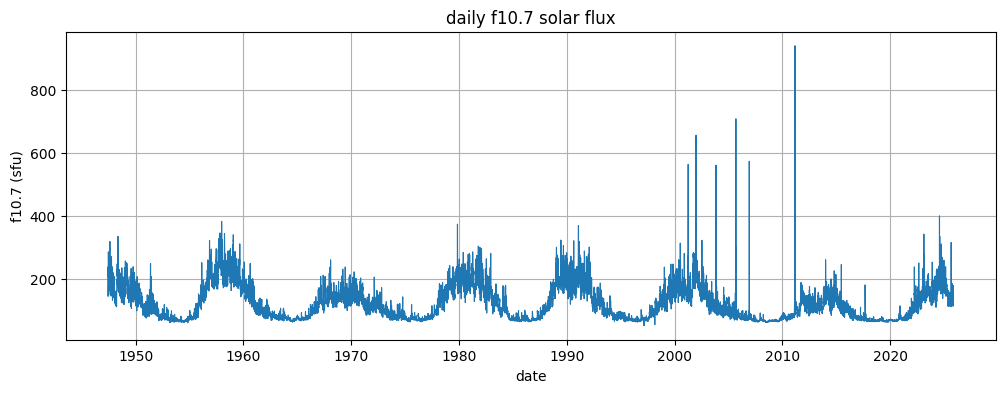

In [6]:
plt.figure(figsize=(12, 4))
plt.plot(df.index, df["F10.7obs"], linewidth=0.8)
plt.title("daily f10.7 solar flux")
plt.xlabel("date")
plt.ylabel("f10.7 (sfu)")
plt.grid(True)
plt.show()

# Evaluation
This section defines the walk-forward evaluation framework used for all models in Phase 3.
All models, including the persistence baseline, are evaluated under identical real-time conditions.

In [7]:
def walk_forward_evaluate(df_full, eval_index, horizon, predict_fn):
    results = []

    for t in eval_index:
        t_future = t + pd.Timedelta(days=horizon)

        if t_future not in df_full.index:
            continue

        train_df = df_full.loc[:t]

        y_true = df_full.loc[t_future, "F10.7obs"]
        y_pred = predict_fn(train_df, t)

        err = y_pred - y_true

        results.append({
            "date": t,
            "y_true": y_true,
            "y_pred": y_pred,
            "abs_error": abs(err),
            "squared_error": err ** 2
        })

    return pd.DataFrame(results).set_index("date")


# Persistence Baseline


In [8]:
def persistence_predictor(train_df, t):
    return train_df.loc[t, "F10.7obs"]
    
eval_index = df_cycle25.index

persistence_results = walk_forward_evaluate(
    df_full=df,
    eval_index=eval_index,
    horizon=CONFIG["HORIZON_DAYS"],
    predict_fn=persistence_predictor
)


print(persistence_results.head())
print(len(persistence_results))

mae = persistence_results["abs_error"].mean()
rmse = np.sqrt(persistence_results["squared_error"].mean())

model_metrics["persistence"] = {
    "mae": mae,
    "rmse": rmse
}

print("persistence mae:", mae)
print("persistence rmse:", rmse)


            y_true  y_pred  abs_error  squared_error
date                                                
2019-12-01    71.6    71.2        0.4           0.16
2019-12-02    70.7    70.4        0.3           0.09
2019-12-03    70.6    69.9        0.7           0.49
2019-12-04    70.7    69.6        1.1           1.21
2019-12-05    70.5    70.7        0.2           0.04
2148
persistence mae: 18.875139664804472
persistence rmse: 29.194844382998276


# Note on Metric Differences vs Phase 2

Phase 2 and Phase 3 metrics are **NOT** directly comparable.

Phase 2 computed errors in a single vectorized pass over historical data, after full cycles had already completed.

This evaluates average similarity between F10.7(t) and F10.7(t+7) in hindsight, without enforcing real-time constraints.


Phase 3 uses strict walk-forward evaluation:

- Each prediction is made using only data available up to time t.

- Errors are accumulated sequentially over Solar Cycle 25.

- Regime changes and active periods are experienced in order and cannot be averaged away.

As a result, Phase 3 error values are expected to be higher and represent a more realistic estimate of real-time 7-day forecasting performance.

> Phase 2 effectively evaluated predictions from over a decade ago, whereas the latest cycle reflects real-time prediction conditions.

# Linear Regression

The following linear regression variants were evaluated under the Phase 3 walk-forward framework:

- **Flux-only**
- **7, 14, & 27 Day Flux Lags** (t−1 … t−N)
- **Flux + AP** (current-day Ap only)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ AP** (current-day Ap only)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ 14 & 27 Day Ap Lags** (t−1 … t−N)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ 3 Day AP Mean, Max Lags** (t-1, t-2, t-3)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ SSN** (current-day SSN only)
- **14 & 27 Day Flux Lags** (t−1 … t−N) **+ 14 & 27 Day SSN Lags** (t−1 … t−N)

All models were compared directly against the persistence baseline using identical evaluation conditions.


## Flux Only

In [9]:
from sklearn.linear_model import LinearRegression

def linreg_no_lag_predictor(train_df, t):
    # prepare training data
    X = train_df[["F10.7obs"]].values
    y = train_df["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"]).dropna().values

    X = X[:len(y)]

    model = LinearRegression()
    model.fit(X, y)

    # predict using current value at time t
    x_t = train_df.loc[t, ["F10.7obs"]].values.reshape(1, -1)
    return model.predict(x_t)[0]

linreg_no_lag_results = walk_forward_evaluate(
    df_full=df,
    eval_index=df_cycle25.index,
    horizon=CONFIG["HORIZON_DAYS"],
    predict_fn=linreg_no_lag_predictor
)

linreg_mae = linreg_no_lag_results["abs_error"].mean()
linreg_rmse = np.sqrt(linreg_no_lag_results["squared_error"].mean())

print("linreg (no lag) mae:", linreg_mae)
print("linreg (no lag) rmse:", linreg_rmse)


linreg (no lag) mae: 18.99616084004402
linreg (no lag) rmse: 27.944870908045075


## 7, 14, & 27 Day Flux Lags

In [10]:
def make_linreg_lag_predictor(n_lags):
    def predictor(train_df, t):
        lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]

        data = train_df[lag_cols].copy()
        data["y"] = data["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
        data = data.dropna()

        X = data[lag_cols].values
        y = data["y"].values

        model = LinearRegression()
        model.fit(X, y)

        x_t = train_df.loc[t, lag_cols].values.reshape(1, -1)
        return model.predict(x_t)[0]

    return predictor

for n_lags in [7, 14, 27]:
    results = walk_forward_evaluate(
        df_full=df,
        eval_index=df_cycle25.index,
        horizon=CONFIG["HORIZON_DAYS"],
        predict_fn=make_linreg_lag_predictor(n_lags)
    )

    mae = results["abs_error"].mean()
    rmse = np.sqrt(results["squared_error"].mean())

    model_name = f"linreg_flux_{n_lags}_lags"

    model_metrics[model_name] = {
        "mae": mae,
        "rmse": rmse
    }

    print(f"{model_name} mae:", mae)
    print(f"{model_name} rmse:", rmse)
    print()



linreg_flux_7_lags mae: 17.87634159887716
linreg_flux_7_lags rmse: 26.766617165842355

linreg_flux_14_lags mae: 15.25193387753459
linreg_flux_14_lags rmse: 23.215310450950533

linreg_flux_27_lags mae: 14.315455156391467
linreg_flux_27_lags rmse: 21.89968963393116



## Flux + AP

In [11]:
def linreg_daily_flux_ap_predictor(train_df, t):
    feature_cols = ["F10.7obs", "Ap"]

    data = train_df[feature_cols].copy()
    data["y"] = data["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = LinearRegression()
    model.fit(X, y)

    x_t = train_df.loc[t, feature_cols].values.reshape(1, -1)
    return model.predict(x_t)[0]

results = walk_forward_evaluate(
    df_full=df,
    eval_index=df_cycle25.index,
    horizon=CONFIG["HORIZON_DAYS"],
    predict_fn=linreg_daily_flux_ap_predictor
)

mae = results["abs_error"].mean()
rmse = np.sqrt(results["squared_error"].mean())

model_metrics["linreg_daily_flux_ap"] = {
    "mae": mae,
    "rmse": rmse
}

print("linreg (daily flux + ap) mae:", mae)
print("linreg (daily flux + ap) rmse:", rmse)



linreg (daily flux + ap) mae: 19.027217277008596
linreg (daily flux + ap) rmse: 27.940376870523238


## 14 & 27 Day Flux Lags + AP

In [12]:
def linreg_flux_ap_predictor(train_df, t, n_lags):
    lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]
    feature_cols = lag_cols + ["Ap"]

    data = train_df[feature_cols].copy()
    data["y"] = data["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = LinearRegression()
    model.fit(X, y)

    x_t = train_df.loc[t, feature_cols].values.reshape(1, -1)
    return model.predict(x_t)[0]

for n_lags in [14, 27]:
    results = walk_forward_evaluate(
        df_full=df,
        eval_index=df_cycle25.index,
        horizon=CONFIG["HORIZON_DAYS"],
        predict_fn=lambda train_df, t, n=n_lags: linreg_flux_ap_predictor(train_df, t, n)
    )

    mae = results["abs_error"].mean()
    rmse = np.sqrt(results["squared_error"].mean())

    model_name = f"linreg_flux_{n_lags}_lags_ap"

    model_metrics[model_name] = {
        "mae": mae,
        "rmse": rmse
    }

    print(f"{model_name} mae:", mae)
    print(f"{model_name} rmse:", rmse)
    print()



linreg_flux_14_lags_ap mae: 15.29997047293217
linreg_flux_14_lags_ap rmse: 23.21451900897251

linreg_flux_27_lags_ap mae: 14.34666348653885
linreg_flux_27_lags_ap rmse: 21.89625213821935



## 14 & 27 Day Flux Lags + 14 & 27 Day AP Lags

In [13]:
from sklearn.linear_model import LinearRegression

def linreg_flux_ap_lags_predictor(train_df, t, n_lags):
    flux_lag_cols =  ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]
    ap_lag_cols = ["Ap"] +[f"ap_lag_{i}" for i in range(1, n_lags + 1)]

    feature_cols = flux_lag_cols + ap_lag_cols

    data = train_df[feature_cols].copy()
    data["y"] = data["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = LinearRegression()
    model.fit(X, y)

    x_t = train_df.loc[t, feature_cols].values.reshape(1, -1)
    return model.predict(x_t)[0]

for n_lags in [14, 27]:
    results = walk_forward_evaluate(
        df_full=df,
        eval_index=df_cycle25.index,
        horizon=CONFIG["HORIZON_DAYS"],
        predict_fn=lambda train_df, t, n=n_lags: linreg_flux_ap_lags_predictor(train_df, t, n)
    )

    mae = results["abs_error"].mean()
    rmse = np.sqrt(results["squared_error"].mean())

    model_name = f"linreg_flux_{n_lags}_lags_ap_{n_lags}_lags"

    model_metrics[model_name] = {
        "mae": mae,
        "rmse": rmse
    }

    print(f"{model_name} mae:", mae)
    print(f"{model_name} rmse:", rmse)
    print()


linreg_flux_14_lags_ap_14_lags mae: 15.35967334804452
linreg_flux_14_lags_ap_14_lags rmse: 23.221307101759926

linreg_flux_27_lags_ap_27_lags mae: 14.473254227741993
linreg_flux_27_lags_ap_27_lags rmse: 21.901085314181366



## 14 & 27 Day Flux Lags + 3 Day AP Mean, Max Lags

In [15]:
from sklearn.linear_model import LinearRegression

def linreg_flux_ap_phase2_style_predictor(train_df, t):
    flux_lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, 28)]
    ap_cols = [
        "ap_mean", "ap_max",
        "ap_mean_lag1", "ap_max_lag1",
        "ap_mean_lag2", "ap_max_lag2",
        "ap_mean_lag3", "ap_max_lag3"
    ]

    feature_cols = flux_lag_cols + ap_cols

    data = train_df[feature_cols].copy()
    data["y"] = data["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = LinearRegression()
    model.fit(X, y)

    x_t = train_df.loc[t, feature_cols].values.reshape(1, -1)
    return model.predict(x_t)[0]


results = walk_forward_evaluate(
    df_full=df,
    eval_index=df_cycle25.index,
    horizon=CONFIG["HORIZON_DAYS"],
    predict_fn=linreg_flux_ap_phase2_style_predictor
)

mae = results["abs_error"].mean()
rmse = np.sqrt(results["squared_error"].mean())

model_metrics["linreg_flux_27_lags_ap_phase2_style"] = {
    "mae": mae,
    "rmse": rmse
}

print("linreg (27 flux lags + phase2-style ap) mae:", mae)
print("linreg (27 flux lags + phase2-style ap) rmse:", rmse)



linreg (27 flux lags + phase2-style ap) mae: 14.352735687490572
linreg (27 flux lags + phase2-style ap) rmse: 21.88987339773187


## 14 & 27 Day Flux Lags + SSN

In [16]:
from sklearn.linear_model import LinearRegression

def linreg_flux_ssn_predictor(train_df, t, n_lags):
    flux_lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]
    feature_cols = flux_lag_cols + ["SN"]

    data = train_df[feature_cols].copy()
    data["y"] = train_df["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = LinearRegression()
    model.fit(X, y)

    x_t = train_df.loc[t, feature_cols].values.reshape(1, -1)
    return model.predict(x_t)[0]


for n_lags in [14, 27]:
    results = walk_forward_evaluate(
        df_full=df,
        eval_index=df_cycle25.index,
        horizon=CONFIG["HORIZON_DAYS"],
        predict_fn=lambda train_df, t, n=n_lags:
            linreg_flux_ssn_predictor(train_df, t, n)
    )

    mae = results["abs_error"].mean()
    rmse = np.sqrt(results["squared_error"].mean())

    model_name = f"linreg_flux_{n_lags}_lags_ssn"

    model_metrics[model_name] = {
        "mae": mae,
        "rmse": rmse
    }

    print(f"{model_name} mae:", mae)
    print(f"{model_name} rmse:", rmse)
    print()



linreg_flux_14_lags_ssn mae: 15.182727995877741
linreg_flux_14_lags_ssn rmse: 23.2408047646196

linreg_flux_27_lags_ssn mae: 14.253586762588956
linreg_flux_27_lags_ssn rmse: 21.9250225223607



## 14 & 27 Day Flux Lags + 14 & 27 Day SSN Lags

In [17]:
def linreg_flux_ssn_lags_predictor(train_df, t, n_lags):
    flux_lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, n_lags + 1)]
    ssn_lag_cols = ["SN"] + [f"sn_lag_{i}" for i in range(1, n_lags + 1)]

    feature_cols = flux_lag_cols + ssn_lag_cols

    data = train_df[feature_cols].copy()
    data["y"] = data["F10.7obs"].shift(-CONFIG["HORIZON_DAYS"])
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = LinearRegression()
    model.fit(X, y)

    x_t = train_df.loc[t, feature_cols].values.reshape(1, -1)
    return model.predict(x_t)[0]

for n_lags in [14, 27]:
    results = walk_forward_evaluate(
        df_full=df,
        eval_index=df_cycle25.index,
        horizon=CONFIG["HORIZON_DAYS"],
        predict_fn=lambda train_df, t, n=n_lags:
            linreg_flux_ssn_lags_predictor(train_df, t, n)
    )

    mae = results["abs_error"].mean()
    rmse = np.sqrt(results["squared_error"].mean())

    model_name = f"linreg_flux_{n_lags}_lags_ssn_{n_lags}_lags"

    model_metrics[model_name] = {
        "mae": mae,
        "rmse": rmse
    }

    print(f"{model_name} mae:", mae)
    print(f"{model_name} rmse:", rmse)
    print()


linreg_flux_14_lags_ssn_14_lags mae: 15.051699856130671
linreg_flux_14_lags_ssn_14_lags rmse: 23.04371392725932

linreg_flux_27_lags_ssn_27_lags mae: 14.167318851644815
linreg_flux_27_lags_ssn_27_lags rmse: 21.919301909911844



In [18]:
metrics_df = (
    pd.DataFrame(model_metrics)
    .T
    .sort_values(by=["mae", "rmse"])
)

metrics_df


,mae,rmse
linreg_flux_27_lags_ssn_27_lags,14.167319,21.919302
linreg_flux_27_lags_ssn,14.253587,21.925023
linreg_flux_27_lags,14.315455,21.899690
linreg_flux_27_lags_ap,14.346663,21.896252
linreg_flux_27_lags_ap_phase2_style,14.352736,21.889873
linreg_flux_27_lags_ap_27_lags,14.473254,21.901085
linreg_flux_14_lags_ssn_14_lags,15.051700,23.043714
linreg_flux_14_lags_ssn,15.182728,23.240805
linreg_flux_14_lags,15.251934,23.215310
linreg_flux_14_lags_ap,15.299970,23.214519


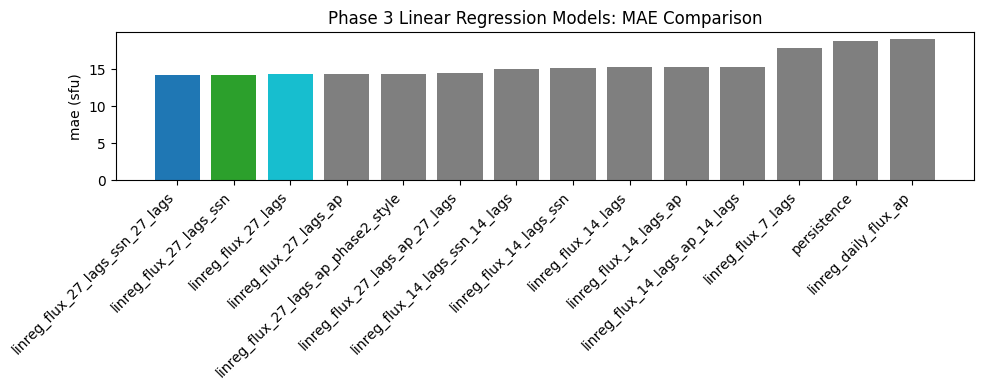

In [20]:
# identify three best models by mae
top3 = metrics_df.nsmallest(3, "mae").index.tolist()

highlight_colors = ["tab:blue", "tab:green", "tab:cyan"]

color_map = {}
for idx, model in enumerate(top3):
    color_map[model] = highlight_colors[idx]

colors = [
    color_map[idx] if idx in color_map else "tab:gray"
    for idx in metrics_df.index
]

plt.figure(figsize=(10, 4))
plt.bar(metrics_df.index, metrics_df["mae"], color=colors)
plt.xticks(rotation=45, ha="right")
plt.ylabel("mae (sfu)")
plt.title("Phase 3 Linear Regression Models: MAE Comparison")
plt.tight_layout()
plt.show()


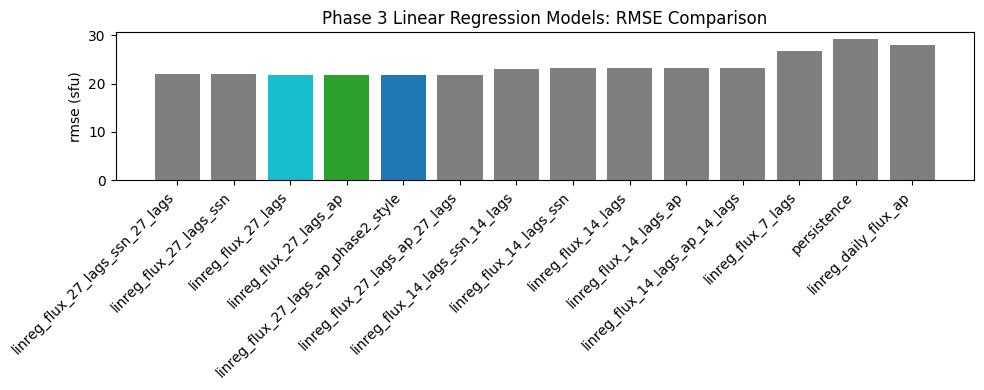

In [21]:
# identify three best models by rmse
top3 = metrics_df.nsmallest(3, "rmse").index.tolist()

highlight_colors = ["tab:blue", "tab:green", "tab:cyan"]

color_map = {}
for idx, model in enumerate(top3):
    color_map[model] = highlight_colors[idx]

colors = [
    color_map[idx] if idx in color_map else "tab:gray"
    for idx in metrics_df.index
]

plt.figure(figsize=(10, 4))
plt.bar(metrics_df.index, metrics_df["rmse"], color=colors)
plt.xticks(rotation=45, ha="right")
plt.ylabel("rmse (sfu)")
plt.title("Phase 3 Linear Regression Models: RMSE Comparison")
plt.tight_layout()
plt.show()


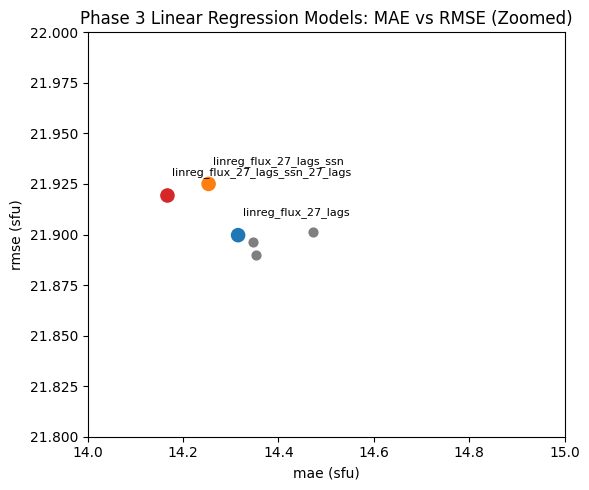

In [28]:
plt.figure(figsize=(6, 5))

plt.scatter(metrics_df["mae"], metrics_df["rmse"], color="tab:gray", s=40)

top3 = metrics_df.nsmallest(3, "mae")

plt.scatter(
    top3["mae"],
    top3["rmse"],
    color=["tab:red", "tab:orange", "tab:blue"],
    s=90
)

for name, row in top3.iterrows():
    plt.text(
        row["mae"] + 0.01,
        row["rmse"] + 0.01,
        name,
        fontsize=8
    )

# tighter zoom
plt.xlim(14, 15)
plt.ylim(21.8, 22)

plt.xlabel("mae (sfu)")
plt.ylabel("rmse (sfu)")
plt.title("Phase 3 Linear Regression Models: MAE vs RMSE (Zoomed)")
plt.tight_layout()
plt.show()



## Linear Regression Results

Linear regression models were evaluated under strict walk-forward conditions on **Solar Cycle 25**, using the **persistence baseline** as the primary reference.  
All models were trained using an expanding window (all data available up to time *t*) and evaluated on *t + 7*.

### Key Findings

- **Persistence is a strong baseline**, but it is consistently beatable by linear models with sufficient temporal context.
- **Lag depth is the dominant factor** in linear model performance.
  - Performance improves substantially from short memory (≤7 days) to moderate memory (~14 days).
  - Improvements from **14 to 27 days are present but relatively small**, indicating diminishing returns beyond two weeks of history.
- **Geomagnetic indices (Ap)** do not materially improve 7-day forecasts.
  - Ap was tested in its strongest form using **dense lag stacks** (Ap(t), ap\_lag\_1 … ap\_lag\_N).
  - Adding Ap, with or without dense lag histories, provides negligible benefit and can slightly degrade performance.
- **Sunspot number (SSN)** provides a modest but consistent improvement.
  - SSN adds complementary long-term solar-cycle context that slightly improves performance beyond flux-only models.
- Short-term **Phase-2-style Ap features** (rolling mean/max with short lags) were re-evaluated under walk-forward conditions.
  - These features do **not** provide additional benefit in real-time forecasting, indicating their earlier gains were largely retrospective rather than predictive.

### Lag Depth Tradeoff: 14 vs 27 Days

While models using ~27 days of flux history consistently perform best, the **performance gap between 14-day and 27-day lag models is small**. This suggests that:

- Most of the useful linear signal is captured within approximately **two weeks** of historical flux data.
- Extending memory to a full solar rotation provides incremental gains rather than a qualitative improvement.
- The system exhibits clear **diminishing returns with increasing lag depth** in linear models.

As a result, **14-day lag models** represent an efficient baseline, while **27-day lag models** serve as an upper bound on linear performance.

### Best Linear Models (Phase 3)

| Model                              | MAE        | RMSE       |
|-----------------------------------|------------|------------|
| linreg_flux_27_lags_ssn_27_lags   | 14.167319  | 21.919302  |
| linreg_flux_27_lags_ssn           | 14.253587  | 21.925023  |
| linreg_flux_27_lags               | 14.315455  | 21.899690  |
| linreg_flux_27_lags_ap            | 14.346663  | 21.896252  |
| linreg_flux_27_lags_ap_phase2_style | 14.352736 | 21.889873  |
| linreg_flux_27_lags_ap_27_lags    | 14.473254  | 21.901085  |


### Conclusion

Linear regression captures the majority of predictable structure in 7-day F10.7 forecasting when sufficient temporal context is provided.  
However, gains beyond ~14 days of memory are modest, and additional linear features yield diminishing improvements.  

These results establish a **realistic performance ceiling for index-only linear models** and motivate the transition to **nonlinear approaches or richer solar observations** for further improvement.


## Export: Linear Regression (27-Day Flux Lags + SSN)


In [31]:
import joblib

def train_export_linreg_flux_ssn(train_df, n_lags, horizon):
    flux_lag_cols = ["F10.7obs"] + [f"f107_lag_{i}" for i in range(1, CONFIG["N_LAGS"] + 1)]
    feature_cols = flux_lag_cols + ["SN"]

    data = train_df[feature_cols].copy()
    data["y"] = data["F10.7obs"].shift(-horizon)
    data = data.dropna()

    X = data[feature_cols].values
    y = data["y"].values

    model = LinearRegression()
    model.fit(X, y)

    return model, feature_cols

train_df = df.loc[:df_cycle25.index[0]]

model, feature_cols = train_export_linreg_flux_ssn(
    train_df=train_df,
    n_lags=CONFIG["N_LAGS"],
    horizon=CONFIG["HORIZON_DAYS"]
)

joblib.dump(
    {
        "model": model,
        "features": feature_cols,
        "n_lags": CONFIG["N_LAGS"],
        "horizon": CONFIG["HORIZON_DAYS"]
    },
    "linreg_flux_27_lags_ssn.pkl"
)

print("Exported linreg_flux_27_lags_ssn.pkl")


Exported linreg_flux_27_lags_ssn.pkl


In [33]:
def predict_export_linreg_flux_lags_sn(df_latest, model_path):
    bundle = joblib.load(model_path)
    model = bundle["model"]
    features = bundle["features"]

    x = df_latest.iloc[-1][features].values.reshape(1, -1)
    return float(model.predict(x)[0])

bundle = joblib.load("linreg_flux_27_lags_ssn.pkl")
features = bundle["features"]

missing = [f for f in features if f not in df.columns]
print("Missing features:", missing)

pred = predict_export_linreg_flux_lags_sn(
    df_latest=df,
    model_path="linreg_flux_27_lags_ssn.pkl"
)

print("Predicted F10.7 (t + H):", pred)


t = df.index[-1]
persistence = df.loc[t, "F10.7obs"]

print("Persistence:", persistence)
print("LinReg:", pred)
print("Delta:", pred - persistence)

t_test = df_cycle25.index[10]  # any valid index
df_slice = df.loc[:t_test]

pred_test = predict_export_linreg_flux_lags_sn(
    df_latest=df_slice,
    model_path="linreg_flux_27_lags_ssn.pkl"
)

true_val = df.loc[
    t_test + pd.Timedelta(days=CONFIG["HORIZON_DAYS"]),
    "F10.7obs"
]

print("Predicted:", pred_test)
print("Actual:", true_val)
print("Abs Error:", abs(pred_test - true_val))


Missing features: []
Predicted F10.7 (t + H): 132.1941824614544
Persistence: 155.9
LinReg: 132.1941824614544
Delta: -23.705817538545602
Predicted: 71.8773025998733
Actual: 70.2
Abs Error: 1.6773025998733004
